# ĐỒ ÁN: DỰ ĐOÁN CHẤT LƯỢNG KHÔNG KHÍ TẠI VIỆT NAM VÀ CẢNH BÁO SỨC KHỎE
**Nhóm sinh viên:** Nhóm 11 [cite: 64]  
**Bộ dữ liệu:** Dữ liệu Chất lượng không khí & Khí tượng tại Hà Nội, TP.HCM, Đà Nẵng 

---

## Mục lục
- [1. Giới thiệu bài toán & Phương pháp thu thập dữ liệu](#1)
  - [1.1 Giới thiệu bài toán](#1-1)
  - [1.2 Nguồn dữ liệu & Tổ chức thư mục](#1-2)
- [2. Làm sạch và Tiền xử lý dữ liệu bước đầu](#2)
  - [2.1 Load & Mô tả Dataset](#2-1)
  - [2.2 Xử lý Missing Values & Trùng lặp](#2-2)
  - [2.3 Chuẩn hóa kiểu dữ liệu](#2-3)
- [3. Phân tích Khám phá Dữ liệu (EDA)](#3)
  - [3.1 Thống kê mô tả cơ bản](#3-1)
  - [3.2 Phân bố biến mục tiêu (AQI & Phân lớp AQI)](#3-2)
  - [3.3 Phân tích tương quan & Đa cộng tuyến (Multicollinearity)](#3-3)
  - [3.4 Phát hiện ngoại lệ (Outliers)](#3-4)
- [4. Tiền xử lý dữ liệu cho Mô hình Học máy](#4)
  - [4.1 Feature Engineering & Encode Categorical](#4-1)
  - [4.2 Train/Val/Test Split (Time-Series Split)](#4-2)
  - [4.3 Chuẩn hóa (Scaling)](#4-3)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

# Cấu hình biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = '../data/processed/all_cities.csv'
print('Import thư viện thành công!')

Import thư viện thành công!


<a id='1'></a>
## 1. Giới thiệu bài toán & Phương pháp thu thập dữ liệu

<a id='1-1'></a>
### 1.1 Giới thiệu bài toán
Ô nhiễm không khí đang là vấn đề nghiêm trọng tại các đô thị lớn. Đề tài hướng tới việc xây dựng mô hình học máy giải quyết đồng thời hai bài toán:
1. **Hồi quy (Regression):** Dự đoán giá trị AQI cụ thể trong 24-48 giờ tới.
2. *Phân loại (Classification):** Xác định mức chất lượng không khí (Tốt / Trung bình / Kém / Xấu / Nguy hại) để đưa ra cảnh báo sức khỏe.

<a id='1-2'></a>
### 1.2 Nguồn dữ liệu & Tổ chức thư mục
Dữ liệu được thu thập từ 2 nguồn chính:
* **AQICN:** Dữ liệu lịch sử chất lượng không khí (PM2.5, PM10, O3, NO2, SO2, CO).
* **Open-Meteo:** Dữ liệu khí tượng (nhiệt độ, độ ẩm, tốc độ gió, hướng gió, lượng mưa, mây che phủ).

[cite_start]**Tổ chức thư mục:** Cấu trúc lưu trữ tuân thủ chuẩn quy trình:
* `data/raw/`: Chứa các file thu thập thô riêng rẽ cho từng thành phố (Vd: `airquality_hanoi.csv`, `weather_hanoi.csv`).
* `data/processed/`: Chứa dữ liệu đã được merge theo thời gian cho từng thành phố (`merged_hanoi.csv`,...) và file hợp nhất cuối cùng `all_cities.csv`.

<a id='2'></a>
## 2. Làm sạch và Tiền xử lý dữ liệu bước đầu

<a id='2-1'></a>
### 2.1 Load & Mô tả Dataset
Tiến hành đọc file `all_cities.csv` từ thư mục `processed`. Dữ liệu bao gồm các đặc trưng về môi trường, thời tiết, các đặc trưng thời gian (year, month, hour, season) và các đặc trưng dạng chuỗi thời gian (lag, rolling).

In [5]:
df = pd.read_csv(DATA_PATH)

# Chuyển đổi cột datetime sang định dạng chuẩn của Pandas
df['datetime'] = pd.to_datetime(df['datetime'])

print(f"Kích thước bộ dữ liệu: {df.shape}")
display(df.head())

Kích thước bộ dữ liệu: (98187, 34)


,datetime,pm25,pm10,o3,no2,so2,co,eu_aqi,aqi,city,...,season,pm25_lag_1h,pm25_lag_3h,pm25_lag_6h,pm25_lag_12h,pm25_lag_24h,pm25_roll_6h,pm25_roll_24h,pm25_roll_72h,aqi_category
0,2022-08-05 07:00:00,20.3,29.0,44.0,17.30,8.10,345.0,72.503334,112.822914,Hà Nội,...,Hạ,NaN,NaN,NaN,NaN,NaN,20.299999,20.299999,20.299999,Kém
1,2022-08-05 08:00:00,17.2,24.7,54.0,17.95,9.70,372.0,71.836670,110.739586,Hà Nội,...,Hạ,20.3,NaN,NaN,NaN,NaN,18.750000,18.750000,18.750000,Kém
2,2022-08-05 09:00:00,17.8,25.5,68.0,18.85,11.95,410.0,71.409996,109.406260,Hà Nội,...,Hạ,17.2,NaN,NaN,NaN,NaN,18.433333,18.433333,18.433333,Kém
3,2022-08-05 10:00:00,20.4,29.1,87.0,20.00,14.70,456.0,70.913330,107.854164,Hà Nội,...,Hạ,17.8,20.3,NaN,NaN,NaN,18.925000,18.925000,18.925000,Kém
4,2022-08-05 11:00:00,22.2,31.8,98.0,20.40,15.85,476.0,70.430000,106.343760,Hà Nội,...,Hạ,20.4,17.2,NaN,NaN,NaN,19.580000,19.580000,19.580000,Kém


<a id='2-2'></a>
### 2 Xử lý Missing Values & Trùng lặp (Duplicates)
* Kiểm tra số lượng dòng trùng lặp do lỗi thu thập từ API.
* Đánh giá tỷ lệ dữ liệu thiếu ở các cảm biến đo chất lượng không khí (PM2.5, PM10,...) và khí tượng

In [6]:
# 1. Kiểm tra trùng lặp
duplicates = df.duplicated().sum()
print(f"Số dòng trùng lặp: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Đã loại bỏ các dòng trùng lặp.")

# 2. Kiểm tra tỷ lệ Missing Values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': df.isnull().sum(), 'Missing_Percent(%)': missing_percent})
display(missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Percent(%)', ascending=False))

# Chiến lược Impute: Forward fill (ffill) do tính chất chuỗi thời gian của dữ liệu, 
# hoặc sử dụng Linear Interpolation cho các khoảng trống ngắn.
df.interpolate(method='linear', inplace=True)
df.fillna(method='ffill', inplace=True) # Fill những giá trị NaN ở đầu chuỗi (nếu có)
df.fillna(method='bfill', inplace=True) 
print(f"Số lượng missing values sau xử lý: {df.isnull().sum().sum()}")

Số dòng trùng lặp: 0


,Missing_Count,Missing_Percent(%)
pm25_lag_24h,72,0.073329
pm25_lag_12h,36,0.036665
pm25_lag_6h,18,0.018332
pm25_lag_3h,9,0.009166
pm25_lag_1h,3,0.003055


Số lượng missing values sau xử lý: 0


<a id='3'></a>
## 3. Phân tích Khám phá Dữ liệu (EDA)

<a id='3-1'></a>
### 3.1 Thống kê mô tả cơ bản
Đánh giá các thống kê cơ bản: mean, median, variance, min/max, IQR cho các biến số. Đặc biệt lưu ý đến dải giá trị của `pm2.5` và `aqi`.

In [7]:
numerical_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'temp', 'humidity', 'wind_speed', 'aqi']
display(df[numerical_cols].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
pm25,98187.0,30.09,21.87,0.30,16.00,23.90,36.80,232.80
pm10,98187.0,39.61,26.47,0.40,22.10,32.80,48.35,291.50
o3,98187.0,78.26,54.10,-1.00,38.00,70.00,108.00,418.00
no2,98187.0,21.37,19.65,0.00,6.15,15.20,31.30,170.35
so2,98187.0,17.25,13.96,0.00,5.40,14.80,25.20,104.60
co,98187.0,565.58,426.42,59.00,307.00,449.00,674.00,5784.00
temp,98187.0,25.97,4.41,6.50,23.90,26.15,28.65,41.15
humidity,98187.0,79.66,14.20,21.57,71.45,83.10,90.96,100.00
wind_speed,98187.0,8.86,5.13,0.00,5.08,7.99,11.76,60.72
aqi,98187.0,93.51,39.86,12.06,63.60,83.08,115.14,284.49


<a id='3-2'></a>
### 3.2 Phân bố biến mục tiêu (AQI & Phân lớp AQI)
Kiểm tra xem dữ liệu có bị mất cân bằng (class imbalance) không đối với bài toán Phân loại mức độ AQI.

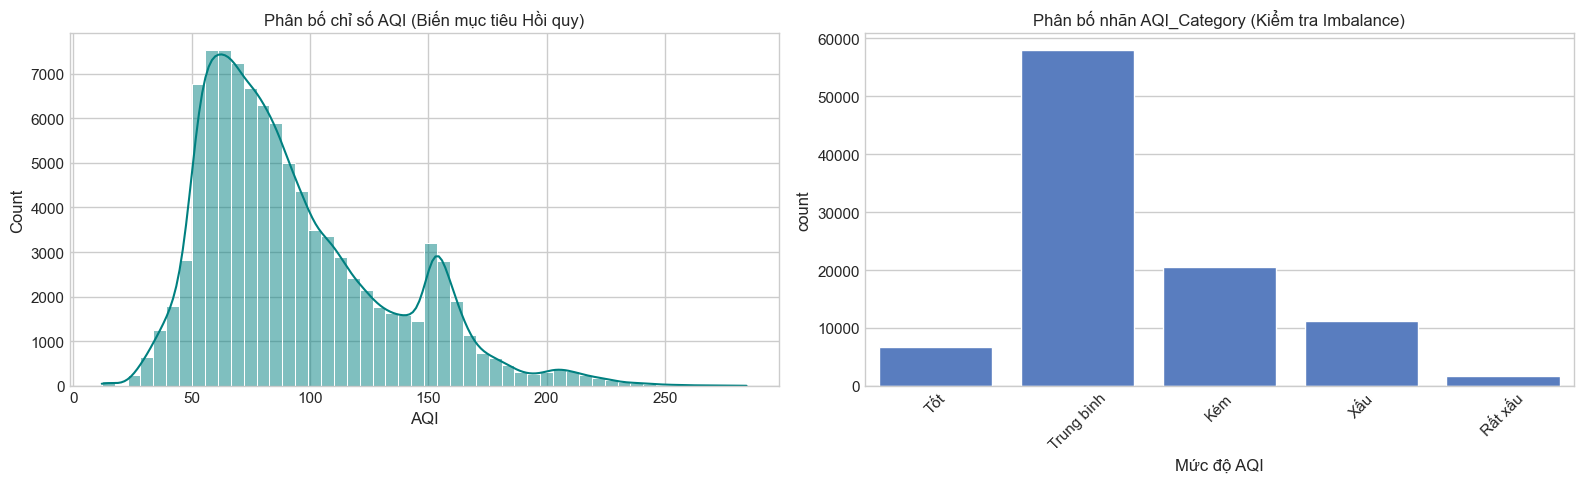

Tỷ lệ các lớp trong aqi_category:
aqi_category
Trung bình    59.06
Kém           20.97
Xấu           11.38
Tốt            6.79
Rất xấu        1.80
Name: proportion, dtype: float64


In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# 1. Phân bố biến liên tục AQI
sns.histplot(df['aqi'], bins=50, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Phân bố chỉ số AQI (Biến mục tiêu Hồi quy)')
ax[0].set_xlabel('AQI')

# 2. Phân bố các nhóm AQI Category
category_order = ["Tốt", "Trung bình", "Kém", "Xấu", "Rất xấu"]

sns.countplot(data=df, x='aqi_category', order=category_order, ax=ax[1])
ax[1].set_title('Phân bố nhãn AQI_Category (Kiểm tra Imbalance)')
ax[1].set_xlabel('Mức độ AQI')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# In tỷ lệ phần trăm
print("Tỷ lệ các lớp trong aqi_category:")
print((df['aqi_category'].value_counts(normalize=True) * 100).round(2))